# 🎬 Movie Success Analysis

Анализ факторов успеха фильмов на основе датасета **TMDB 5000 Movies**.

**Цель проекта** — выяснить, какие характеристики фильма (бюджет, жанр, рейтинг, временные факторы) реально влияют на его финансовый успех, и проверить ряд гипотез статистическими методами.

**Бизнес-вопросы:**
1. Влияет ли бюджет на кассовые сборы и окупаемость (ROI)?
2. Какие бюджетные категории фильмов наиболее уязвимы?
3. Гарантирует ли высокий зрительский рейтинг финансовый успех?
4. Какие жанры показывают наилучшие сборы?
5. Существуют ли «культовые провалы»?

**Стек:** Python, pandas, NumPy, SciPy, Matplotlib, Seaborn

## 1. Загрузка данных

Используем датасет TMDB 5000 Movies с Kaggle. Он состоит из двух файлов: метаданные фильмов и информация о касте/съёмочной группе.

In [1]:
# 1. Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
import zipfile
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal

# 3. Распаковываем архив с данными
archive_path = '/content/drive/MyDrive/кино/archive.zip'
extract_path = '/content/data'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(archive_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Архив распакован")

# 4. Загрузка данных
df_movies = pd.read_csv(f'{extract_path}/tmdb_5000_movies.csv')
df_credits = pd.read_csv(f'{extract_path}/tmdb_5000_credits.csv')

print(f"Загружено фильмов: {len(df_movies)}")
print(f"Записей о касте: {len(df_credits)}")

Mounted at /content/drive
Архив распакован
Загружено фильмов: 4803
Записей о касте: 4803


In [2]:
# Базовая информация о данных
print("=== MOVIES DATASET ===")
print(f"Размер: {df_movies.shape}")
print(f"\nКолонки: {df_movies.columns.tolist()}")
print(f"\nПропуски (топ-10):")
print(df_movies.isnull().sum().sort_values(ascending=False).head(10))

print("\n=== CREDITS DATASET ===")
print(f"Размер: {df_credits.shape}")
print(f"Колонки: {df_credits.columns.tolist()}")

=== MOVIES DATASET ===
Размер: (4803, 20)

Колонки: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Пропуски (топ-10):
homepage          3091
tagline            844
overview             3
runtime              2
release_date         1
id                   0
budget               0
genres               0
original_title       0
popularity           0
dtype: int64

=== CREDITS DATASET ===
Размер: (4803, 4)
Колонки: ['movie_id', 'title', 'cast', 'crew']


## 2. Очистка и предобработка

Объединяем два датасета по `movie_id`, фильтруем фильмы с некорректными значениями бюджета и выручки, обрабатываем выбросы методом IQR.

In [3]:
# Объединение датасетов
df = df_movies.merge(df_credits, left_on='id', right_on='movie_id', suffixes=('_movies', '_credits'))

# Отбрасываем фильмы с нулевым/некорректным бюджетом и выручкой
df_clean = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
df_clean = df_clean[df_clean['budget'] > 10000]

print(f"Объединённый датасет: {df.shape}")
print(f"После очистки: {df_clean.shape}")

Объединённый датасет: (4803, 24)
После очистки: (3213, 24)


In [4]:
# Обработка выбросов по выручке методом IQR
Q1 = df_clean['revenue'].quantile(0.25)
Q3 = df_clean['revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df_clean[
    (df_clean['revenue'] >= lower_bound) &
    (df_clean['revenue'] <= upper_bound)
].copy()

print(f"Q1: {Q1:,.0f} | Q3: {Q3:,.0f} | IQR: {IQR:,.0f}")
print(f"С выбросами:  {df_clean.shape}")
print(f"Без выбросов: {df_no_outliers.shape}")

Q1: 17,292,381 | Q3: 147,298,761 | IQR: 130,006,380
С выбросами:  (3213, 24)
Без выбросов: (2930, 24)


## 3. Feature engineering

Создаём дополнительные признаки для анализа:
- **ROI** (Return on Investment) и его логарифм
- **log_revenue** — логарифмированная выручка для нормализации распределения
- **Категория успеха**: HIT / BREAK_EVEN / FLOP по соотношению выручки и бюджета
- **Временные признаки**: год, месяц, день недели релиза
- **Жанр, режиссёр, топ-3 актёров** — извлекаются из вложенных JSON-полей

In [5]:
# ROI и логарифмическая выручка
df_clean['ROI'] = df_clean['revenue'] / df_clean['budget']
df_clean['log_revenue'] = np.log1p(df_clean['revenue'])
df_clean['log_ROI'] = np.log1p(df_clean['ROI'])

# Категория успеха по соотношению выручки к бюджету
def classify_success(row):
    ratio = row['ROI']
    if ratio >= 2.5:
        return 'HIT'
    elif ratio >= 1.5:
        return 'BREAK_EVEN'
    else:
        return 'FLOP'

df_clean['success_category'] = df_clean.apply(classify_success, axis=1)

print("Распределение по категориям успеха:")
print(df_clean['success_category'].value_counts())

Распределение по категориям успеха:
success_category
HIT           1510
FLOP          1112
BREAK_EVEN     591
Name: count, dtype: int64


In [6]:
# Временные признаки
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean['release_month'] = df_clean['release_date'].dt.month
df_clean['day_of_week'] = df_clean['release_date'].dt.dayofweek

df_clean[['release_date', 'release_year', 'release_month', 'day_of_week']].head()

,release_date,release_year,release_month,day_of_week
0,2009-12-10,2009,12,3
1,2007-05-19,2007,5,5
2,2015-10-26,2015,10,0
3,2012-07-16,2012,7,0
4,2012-03-07,2012,3,2


In [7]:
# Парсинг вложенных JSON-полей

def parse_json_column(x, key='name'):
    """Извлекает список значений по ключу из JSON-строки."""
    if pd.isna(x) or x == '[]':
        return []
    try:
        return [item[key] for item in ast.literal_eval(x)]
    except:
        return []

def get_director(x):
    """Возвращает имя режиссёра из поля crew."""
    if pd.isna(x) or x == '[]':
        return 'Unknown'
    try:
        crew = ast.literal_eval(x)
        for person in crew:
            if person.get('job') == 'Director':
                return person['name']
        return 'Unknown'
    except:
        return 'Unknown'

def get_top_actors(x, n=3):
    """Возвращает топ-N актёров из поля cast по полю order."""
    if pd.isna(x) or x == '[]':
        return []
    try:
        cast = ast.literal_eval(x)
        sorted_cast = sorted(cast, key=lambda p: p.get('order', 999))
        return [p['name'] for p in sorted_cast[:n]]
    except:
        return []

# Применяем функции
df_clean['genres_list'] = df_clean['genres'].apply(parse_json_column)
df_clean['main_genre'] = df_clean['genres_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
df_clean['keywords_list'] = df_clean['keywords'].apply(parse_json_column)
df_clean['director'] = df_clean['crew'].apply(get_director)
df_clean['top_actors'] = df_clean['cast'].apply(get_top_actors)

# Топ-10 жанров
all_genres = [g for genre_list in df_clean['genres_list'] for g in genre_list]
print("Топ-10 жанров по частоте:")
print(pd.Series(all_genres).value_counts().head(10))

Топ-10 жанров по частоте:
Drama              1430
Comedy             1104
Thriller            930
Action              915
Adventure           660
Romance             570
Crime               519
Science Fiction     428
Family              364
Fantasy             340
Name: count, dtype: int64


In [8]:
# Бюджетные группы (квартильное разбиение)
df_clean['budget_group'] = pd.qcut(
    df_clean['budget'],
    q=3,
    labels=['Low budget', 'Mid budget', 'High budget']
)

df_clean.groupby('budget_group', observed=True)['budget'].agg(['min', 'median', 'max', 'count'])

,min,median,max,count
budget_group,,,,
Low budget,12000,6500000.0,15000000,1109
Mid budget,15500000,26000000.0,40000000,1035
High budget,40600000,73000000.0,380000000,1069


## 4. EDA: корреляции и распределения

Изучаем, как числовые признаки связаны с выручкой, и визуализируем основные распределения.

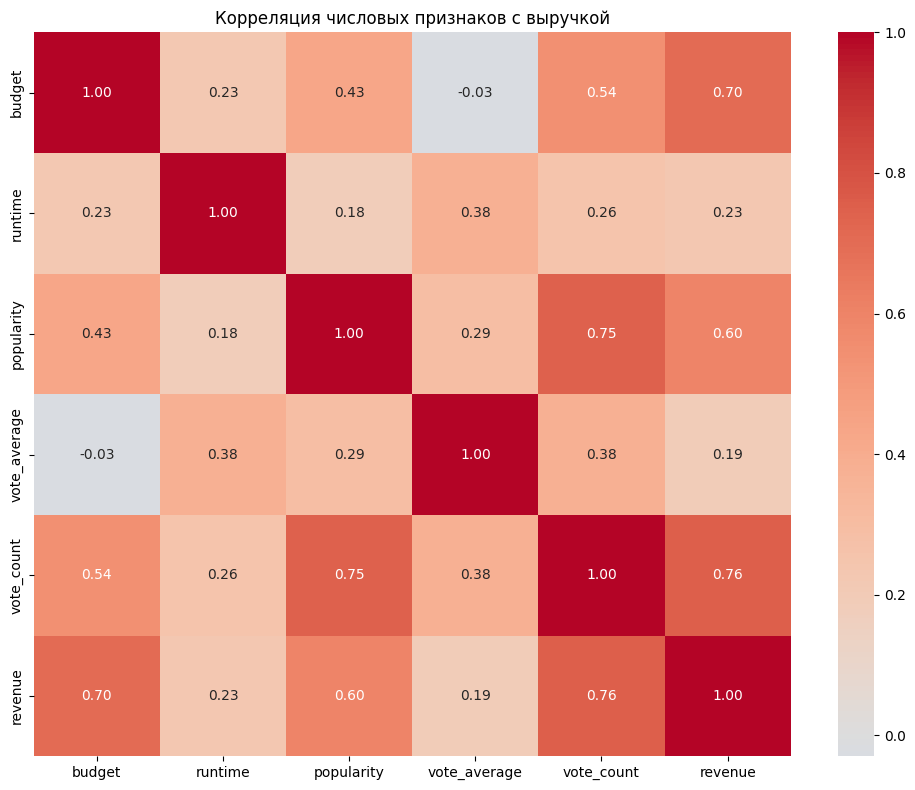

In [9]:
# Корреляционная матрица
numeric_cols = ['budget', 'runtime', 'popularity', 'vote_average', 'vote_count', 'revenue']
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков с выручкой')
plt.tight_layout()
plt.show()

**Что видим:** наиболее сильно с выручкой коррелируют `vote_count` (популярность отзывов) и `budget`. Связь с `vote_average` (средний рейтинг) — слабая. Это первый намёк на то, что высокий рейтинг ещё не означает кассовый успех.

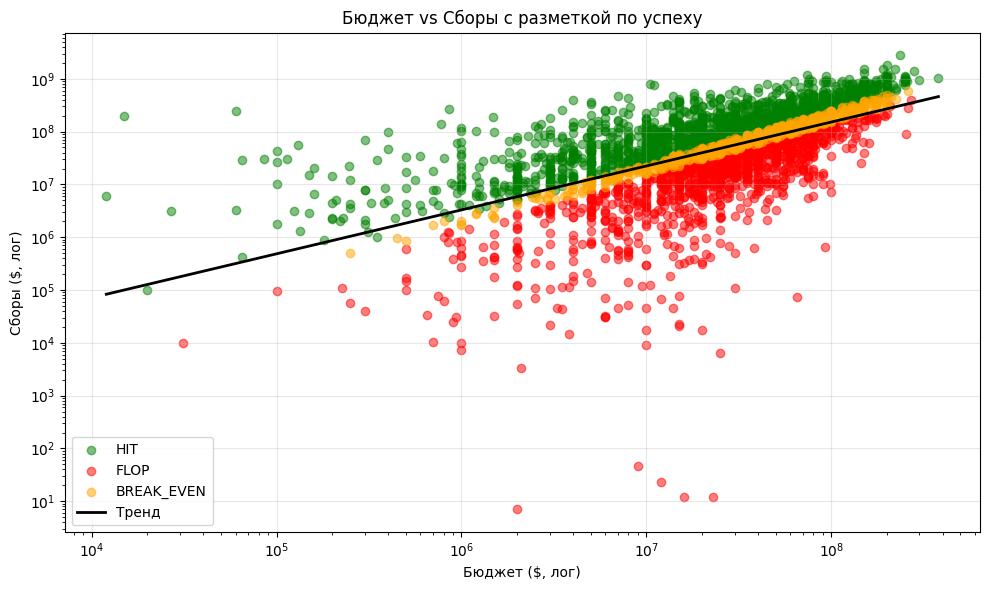

In [10]:
# Бюджет vs Выручка с цветовой разметкой по категории успеха
colors = {'HIT': 'green', 'BREAK_EVEN': 'orange', 'FLOP': 'red'}

plt.figure(figsize=(10, 6))
for category in df_clean['success_category'].unique():
    subset = df_clean[df_clean['success_category'] == category]
    plt.scatter(subset['budget'], subset['revenue'],
                c=colors.get(category, 'gray'),
                label=category, alpha=0.5)

# Линия тренда (на лог-лог шкале)
x = np.log10(df_clean['budget'])
y = np.log10(df_clean['revenue'])
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(10**x_line, 10**poly(x_line), color='black', linewidth=2, label='Тренд')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Бюджет ($, лог)')
plt.ylabel('Сборы ($, лог)')
plt.title('Бюджет vs Сборы с разметкой по успеху')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Что видим:** в логарифмических координатах связь между бюджетом и сборами почти линейная — дорогие фильмы зарабатывают больше в абсолюте. Но цветовая разметка показывает, что провалы (красные точки) встречаются во всех ценовых сегментах.

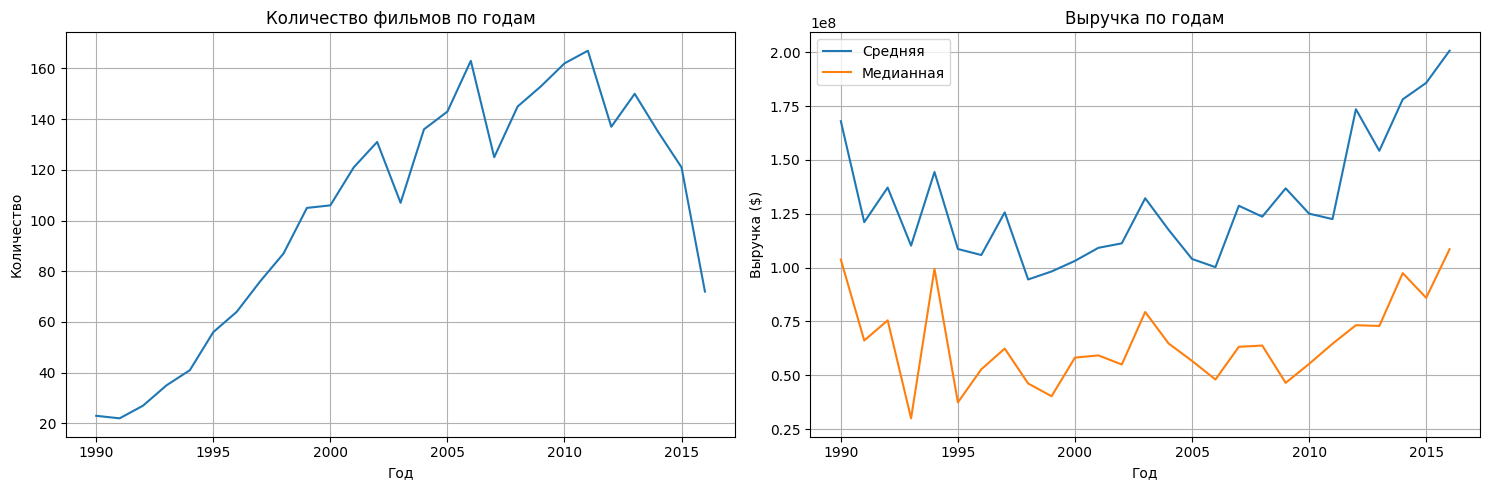

In [11]:
# Динамика индустрии по годам
year_stats = df_clean.groupby('release_year').agg(
    films_count=('title_movies', 'count'),
    revenue_mean=('revenue', 'mean'),
    revenue_median=('revenue', 'median')
).reset_index()
year_stats = year_stats[year_stats['release_year'] >= 1990]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(year_stats['release_year'], year_stats['films_count'])
axes[0].set_title('Количество фильмов по годам')
axes[0].set_xlabel('Год'); axes[0].set_ylabel('Количество'); axes[0].grid(True)

axes[1].plot(year_stats['release_year'], year_stats['revenue_mean'], label='Средняя')
axes[1].plot(year_stats['release_year'], year_stats['revenue_median'], label='Медианная')
axes[1].set_title('Выручка по годам')
axes[1].set_xlabel('Год'); axes[1].set_ylabel('Выручка ($)'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Анализ по бюджетным категориям

Сравниваем медианные сборы и ROI в трёх бюджетных группах. Дополнительно вводим категории по абсолютным порогам для более чёткой интерпретации.

In [12]:
# Сводная статистика по бюджетным группам
budget_summary = df_clean.groupby('budget_group', observed=True).agg(
    films_count=('budget_group', 'count'),
    median_budget=('budget', 'median'),
    median_revenue=('revenue', 'median'),
    median_roi=('ROI', 'median')
)
budget_summary

,films_count,median_budget,median_revenue,median_roi
budget_group,,,,
Low budget,1109,6500000.0,17273593.0,3.118040
Mid budget,1035,26000000.0,52277485.0,1.965000
High budget,1069,73000000.0,164508066.0,2.192626


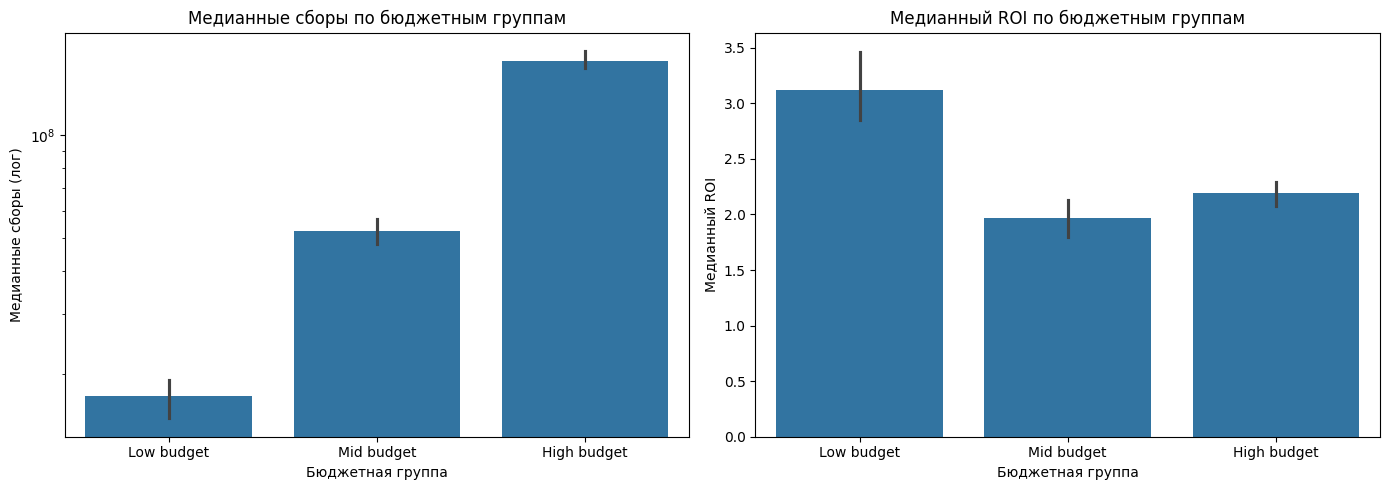

In [13]:
# Визуализация медианных сборов и ROI по бюджетным группам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_clean, x='budget_group', y='revenue',
            estimator=np.median, order=['Low budget', 'Mid budget', 'High budget'],
            ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Медианные сборы по бюджетным группам')
axes[0].set_xlabel('Бюджетная группа')
axes[0].set_ylabel('Медианные сборы (лог)')

sns.barplot(data=df_clean, x='budget_group', y='ROI',
            estimator=np.median, order=['Low budget', 'Mid budget', 'High budget'],
            ax=axes[1])
axes[1].set_title('Медианный ROI по бюджетным группам')
axes[1].set_xlabel('Бюджетная группа')
axes[1].set_ylabel('Медианный ROI')

plt.tight_layout()
plt.show()

**Что видим:** медианные сборы растут с бюджетом, но медианный ROI — наоборот. Малобюджетные фильмы в среднем окупаются лучше относительно вложений.

/tmp/ipykernel_2613/3222500600.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vulnerability_stats, x='budget_category_abs', y='flop_rate_%',


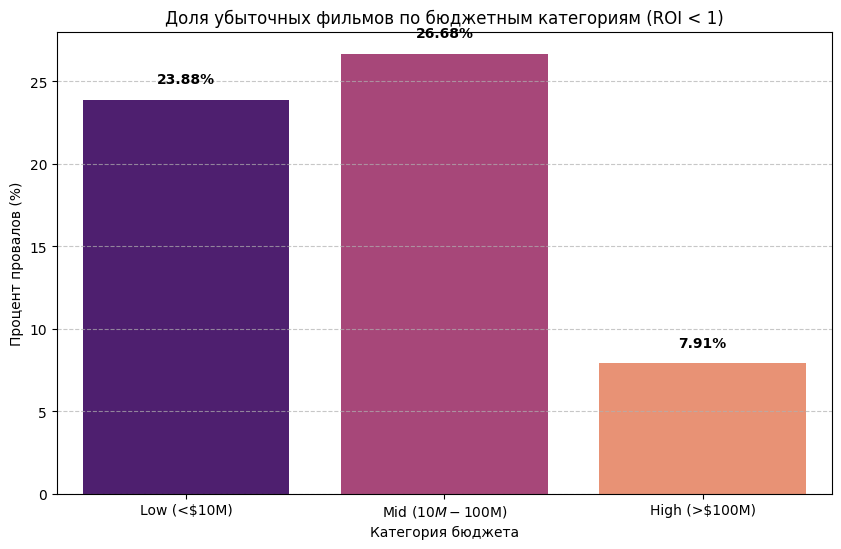

,budget_category_abs,total_films,flops,flop_rate_%
0,Low (<$10M),716,171,23.88
1,Mid ($10M-$100M),2219,592,26.68
2,High (>$100M),278,22,7.91


In [14]:
# Доля убыточных фильмов в каждой бюджетной категории (по абсолютным порогам)
def categorize_budget_abs(x):
    if x < 10_000_000:
        return 'Low (<$10M)'
    elif x <= 100_000_000:
        return 'Mid ($10M-$100M)'
    else:
        return 'High (>$100M)'

df_clean['budget_category_abs'] = df_clean['budget'].apply(categorize_budget_abs)

vulnerability_stats = df_clean.groupby('budget_category_abs').agg(
    total_films=('ROI', 'count'),
    flops=('ROI', lambda x: (x < 1).sum())
).reset_index()
vulnerability_stats['flop_rate_%'] = (
    vulnerability_stats['flops'] / vulnerability_stats['total_films'] * 100
).round(2)

# Упорядочиваем категории
order = ['Low (<$10M)', 'Mid ($10M-$100M)', 'High (>$100M)']
vulnerability_stats['budget_category_abs'] = pd.Categorical(
    vulnerability_stats['budget_category_abs'], categories=order, ordered=True
)
vulnerability_stats = vulnerability_stats.sort_values('budget_category_abs').reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=vulnerability_stats, x='budget_category_abs', y='flop_rate_%',
            palette='magma')
for i, row in vulnerability_stats.iterrows():
    plt.text(i, row['flop_rate_%'] + 1, f"{row['flop_rate_%']}%",
             ha='center', fontweight='bold')
plt.title('Доля убыточных фильмов по бюджетным категориям (ROI < 1)')
plt.ylabel('Процент провалов (%)')
plt.xlabel('Категория бюджета')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

vulnerability_stats

**Ключевой вывод:** среднебюджетные фильмы ($10M–$100M) — самая уязвимая категория. У них нет ни малобюджетной свободы экспериментов, ни маркетингового веса блокбастеров.

## 6. Анализ по жанрам

Какие жанры в среднем приносят больше денег? Сравниваем по средней и медианной выручке.

In [15]:
# Статистика по основному жанру
genre_stats = (
    df_clean.groupby('main_genre')
    .agg(
        films_count=('main_genre', 'count'),
        mean_revenue=('revenue', 'mean'),
        median_revenue=('revenue', 'median')
    )
    .sort_values('mean_revenue', ascending=False)
)
genre_stats.head(10)

,films_count,mean_revenue,median_revenue
main_genre,,,
Animation,99,2.989416e+08,245724603.0
Adventure,287,2.469419e+08,141195658.0
Family,38,2.340616e+08,95268400.5
Science Fiction,78,2.073831e+08,96492738.5
Fantasy,92,1.854043e+08,126038645.0
Action,588,1.555427e+08,72739356.0
History,18,1.007775e+08,44545847.0
Thriller,116,1.007504e+08,63236378.5
Romance,70,9.892815e+07,61274473.5


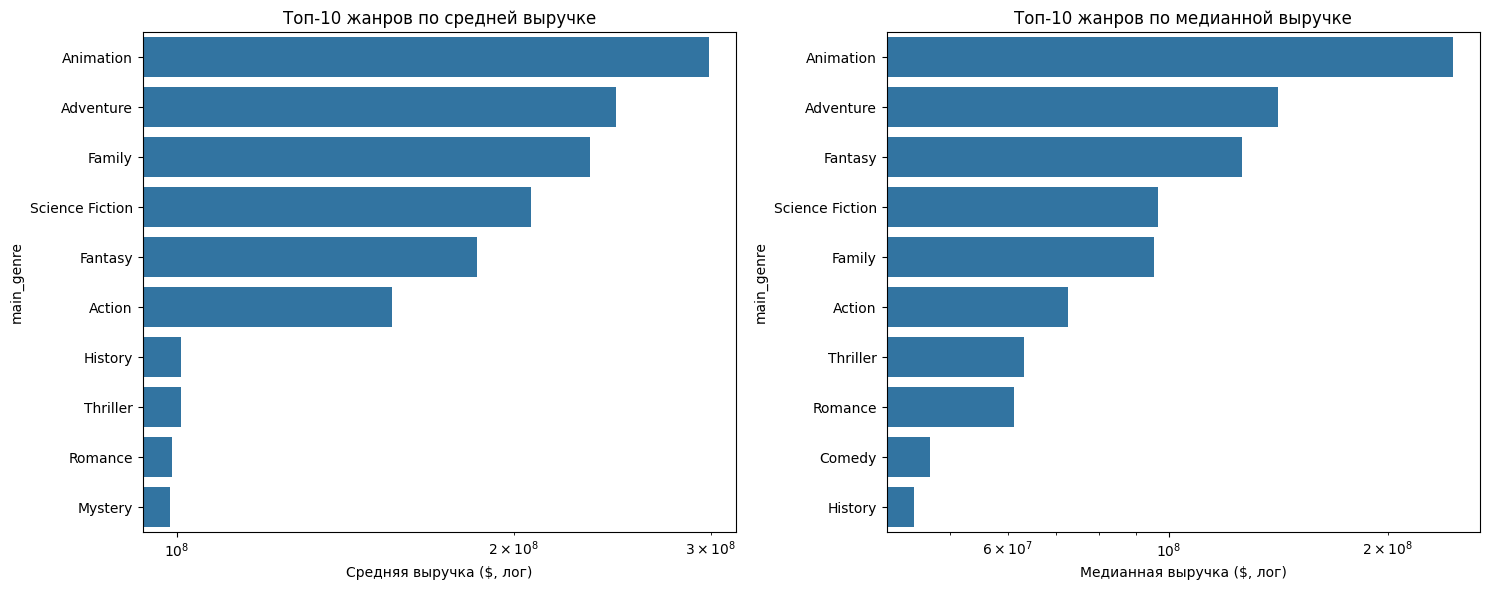

In [16]:
# Топ жанров по средней и медианной выручке
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_mean = genre_stats.sort_values('mean_revenue', ascending=False).head(10)
sns.barplot(x=top_mean['mean_revenue'], y=top_mean.index, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Топ-10 жанров по средней выручке')
axes[0].set_xlabel('Средняя выручка ($, лог)')

top_median = genre_stats.sort_values('median_revenue', ascending=False).head(10)
sns.barplot(x=top_median['median_revenue'], y=top_median.index, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Топ-10 жанров по медианной выручке')
axes[1].set_xlabel('Медианная выручка ($, лог)')

plt.tight_layout()
plt.show()

**Что видим:** Adventure, Animation, Fantasy стабильно лидируют по сборам. Это типичные блокбастерные жанры с высокими бюджетами и кассой.

## 7. Культовые провалы

Гипотеза: высокий зрительский рейтинг не гарантирует кассовый успех. Ищем фильмы с рейтингом ≥ 7.5 и количеством голосов ≥ 1000, которые не окупились в прокате.

In [17]:
# Культовые провалы: высокий рейтинг, но ROI < 1
cult_flops = df_clean[
    (df_clean['vote_average'] >= 7.5) &
    (df_clean['vote_count'] >= 1000) &
    (df_clean['ROI'] < 1)
][['title_movies', 'budget', 'revenue', 'ROI', 'vote_average', 'vote_count']].copy()

cult_flops = cult_flops.sort_values(by=['vote_average', 'ROI'], ascending=[False, True])
print(f"Найдено культовых провалов: {len(cult_flops)}")
cult_flops.head(15)

Найдено культовых провалов: 4


,title_movies,budget,revenue,ROI,vote_average,vote_count
3706,Donnie Darko,6000000,1270522,0.211754,7.7,3452
1920,Warrior,25000000,23057115,0.922285,7.7,1272
977,The Iron Giant,70000000,23159305,0.330847,7.6,1436
1352,Gattaca,36000000,12532777,0.348133,7.5,1808


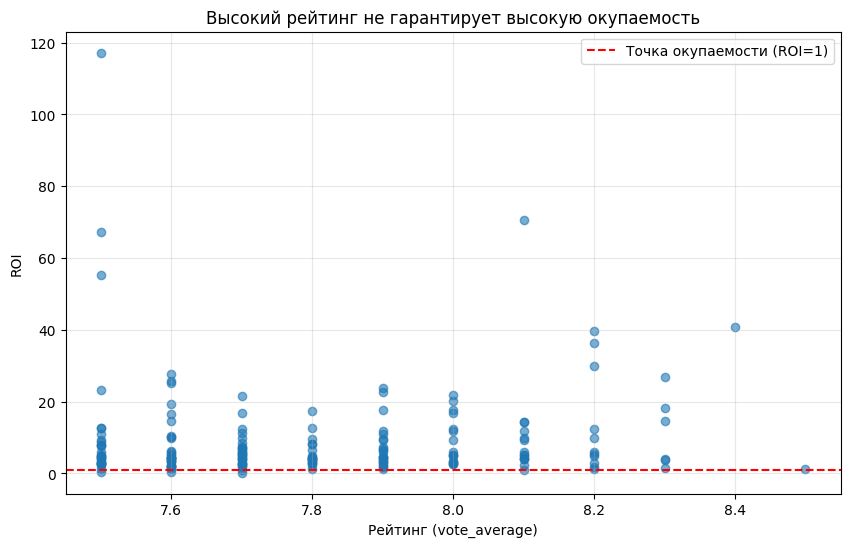

In [18]:
# Визуализация: рейтинг vs ROI для высокорейтинговых фильмов
subset = df_clean[
    (df_clean['vote_average'] >= 7.5) &
    (df_clean['vote_count'] >= 1000)
]

plt.figure(figsize=(10, 6))
plt.scatter(subset['vote_average'], subset['ROI'], alpha=0.6)
plt.axhline(1, color='red', linestyle='--', label='Точка окупаемости (ROI=1)')
plt.title('Высокий рейтинг не гарантирует высокую окупаемость')
plt.xlabel('Рейтинг (vote_average)')
plt.ylabel('ROI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Что видим:** среди фильмов с высоким рейтингом значительная часть находится под красной линией — то есть не окупились. Зрительские оценки и финансовый успех — это разные вещи.

## 8. Проверка статистических гипотез

Подтверждаем визуальные наблюдения статистическими тестами.

**Тесты:**
- **Spearman correlation** — ранговая корреляция бюджета с выручкой и ROI
- **Mann-Whitney U** — сравнение распределений ROI малобюджетных и крупнобюджетных фильмов
- **Kruskal-Wallis** — различия между тремя бюджетными группами по ROI и выручке

In [19]:
# Гипотеза 1: связь бюджета с выручкой и ROI
corr_rev, p_rev = stats.spearmanr(df_clean['budget'], df_clean['revenue'])
corr_roi, p_roi = stats.spearmanr(df_clean['budget'], df_clean['ROI'])

print("Spearman correlation:")
print(f"  Budget vs Revenue: ρ = {corr_rev:.3f}, p-value = {p_rev:.2e}")
print(f"  Budget vs ROI:     ρ = {corr_roi:.3f}, p-value = {p_roi:.2e}")

Spearman correlation:
  Budget vs Revenue: ρ = 0.674, p-value = 0.00e+00
  Budget vs ROI:     ρ = -0.130, p-value = 1.22e-13


**Вывод:** связь бюджета с выручкой сильная и значимая, а с ROI — слабая. Подтверждает наблюдение из EDA.

In [20]:
# Гипотеза 2: малобюджетные фильмы окупаются лучше крупнобюджетных (Mann-Whitney U)
low = df_clean[df_clean['budget_group'] == 'Low budget']['ROI']
high = df_clean[df_clean['budget_group'] == 'High budget']['ROI']

stat, p = mannwhitneyu(low, high, alternative='greater')
print("Mann-Whitney U: Low budget ROI > High budget ROI")
print(f"  p-value = {p:.2e}")
print(f"  Median ROI (Low):  {low.median():.2f}")
print(f"  Median ROI (High): {high.median():.2f}")
print(f"  Размер выборок: Low={len(low)}, High={len(high)}")

Mann-Whitney U: Low budget ROI > High budget ROI
  p-value = 1.50e-14
  Median ROI (Low):  3.12
  Median ROI (High): 2.19
  Размер выборок: Low=1109, High=1069


**Вывод:** p-value очень маленькое — гипотеза подтверждается. Малобюджетные фильмы статистически значимо лучше окупаются.

In [21]:
# Гипотеза 3: различия между тремя бюджетными группами (Kruskal-Wallis)
low = df_clean[df_clean['budget_group'] == 'Low budget']['ROI']
mid = df_clean[df_clean['budget_group'] == 'Mid budget']['ROI']
high = df_clean[df_clean['budget_group'] == 'High budget']['ROI']

stat_roi, p_roi_kw = kruskal(low, mid, high)
print(f"Kruskal-Wallis (ROI): p-value = {p_roi_kw:.2e}")

low_r = df_clean[df_clean['budget_group'] == 'Low budget']['revenue']
mid_r = df_clean[df_clean['budget_group'] == 'Mid budget']['revenue']
high_r = df_clean[df_clean['budget_group'] == 'High budget']['revenue']

stat_rev, p_rev_kw = kruskal(low_r, mid_r, high_r)
print(f"Kruskal-Wallis (Revenue): p-value = {p_rev_kw:.2e}")

Kruskal-Wallis (ROI): p-value = 2.49e-19
Kruskal-Wallis (Revenue): p-value = 7.33e-265


**Вывод:** обе p-value крайне малы — между бюджетными группами есть значимые различия и по ROI, и по выручке.

## 9. Ключевые выводы

1. **Бюджет коррелирует с выручкой, но не с окупаемостью.** Spearman показывает сильную положительную связь между бюджетом и кассовыми сборами, но связь бюджета и ROI слабая. Дорогие фильмы зарабатывают больше в абсолюте, но это не значит, что они выгоднее.

2. **Среднебюджетные фильмы — самая уязвимая категория.** В сегменте $10M–$100M доля убыточных фильмов выше, чем в low- и high-budget группах. У них нет ни малобюджетной свободы экспериментов, ни маркетингового веса блокбастеров.

3. **Малобюджетные фильмы чаще «выстреливают».** Медианный ROI в low-budget группе значительно выше, чем в high-budget. Mann-Whitney U подтверждает это статистически.

4. **Высокий рейтинг ≠ финансовый успех.** Среди фильмов с рейтингом ≥ 7.5 есть целая категория «культовых провалов» — высоко оценённых критиками, но не окупившихся в прокате.

5. **Жанровая разница существенна.** Adventure, Animation, Fantasy стабильно опережают драмы и комедии в кассовых сборах.

### Что можно улучшить

- Построить ML-модель для прогноза `log_revenue` или `success_category`.
- Включить анализ режиссёров и актёров (данные извлечены, но пока не использованы).
- Учесть инфляцию при сравнении сборов фильмов разных лет.
- Расширить анализ временных факторов (сезонность релизов, день недели).